In [26]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import BaseVAE, GlobalVAE, NormalizingGlobalVAE, SteinGlobalVAE, SteinNormalizingVAE



from morbius import make_mobius_strip
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def plot3d(d, title):
    d = d.reshape(-1, 3)
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [3]:
import numpy as np

n_samples = 2000

X_mobius, _  = make_mobius_strip(n_samples=2000, radius = 2, width = 3, noise=0.2)

plot3d(X_mobius, "Möbius Strip")

In [4]:
X_S, t = make_s_curve(noise=0.10, random_state=0, n_samples=1000)
plot3d(X_S, "Curve Data")

In [39]:
X_blobs, _=  make_blobs(centers=2,n_features=3, cluster_std=0.5, random_state=0, n_samples=1000)
plot3d(X_blobs, "Blob Data")

# Basic VAE

In [5]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )




def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )



In [40]:
X = X_blobs 

batch_size = X.shape[0]
dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]

out_dim = X.reshape(X.shape[0], -1).shape[1]
lr=5e-3
hidden_dim = 8
z_dim = 2
adam = optim.Adam(lr)

encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}

In [ ]:
def plot_vae(vae, rng_key, share_axis=True):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({"z": values["z"]}, d_sub)

    has_m = values.get("m") is not None
    c_recon = values.get("pidx")

    plot3d(X_recon["obs"], "recon")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=share_axis, sharey=share_axis)

    axes[0, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_recon)
    axes[0, 0].set_title("recon latent (z)")

    if has_m:
        axes[0, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_recon)
        axes[0, 1].set_title("recon latent (m)")
    else:
        axes[0, 1].axis("off")

    values = vae.sample(s_sub, 1000)
    plot3d(values["obs"], "samples")

    c_samp = values.get("pidx")

    axes[1, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_samp)
    axes[1, 0].set_title("samples latent (z)")

    if has_m:
        axes[1, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_samp)
        axes[1, 1].set_title("samples latent (m)")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [42]:
rng_key, sub_key = jax.random.split(rng_key)

base_vae = BaseVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

base_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




100%|██████████| 10000/10000 [00:11<00:00, 887.39it/s]


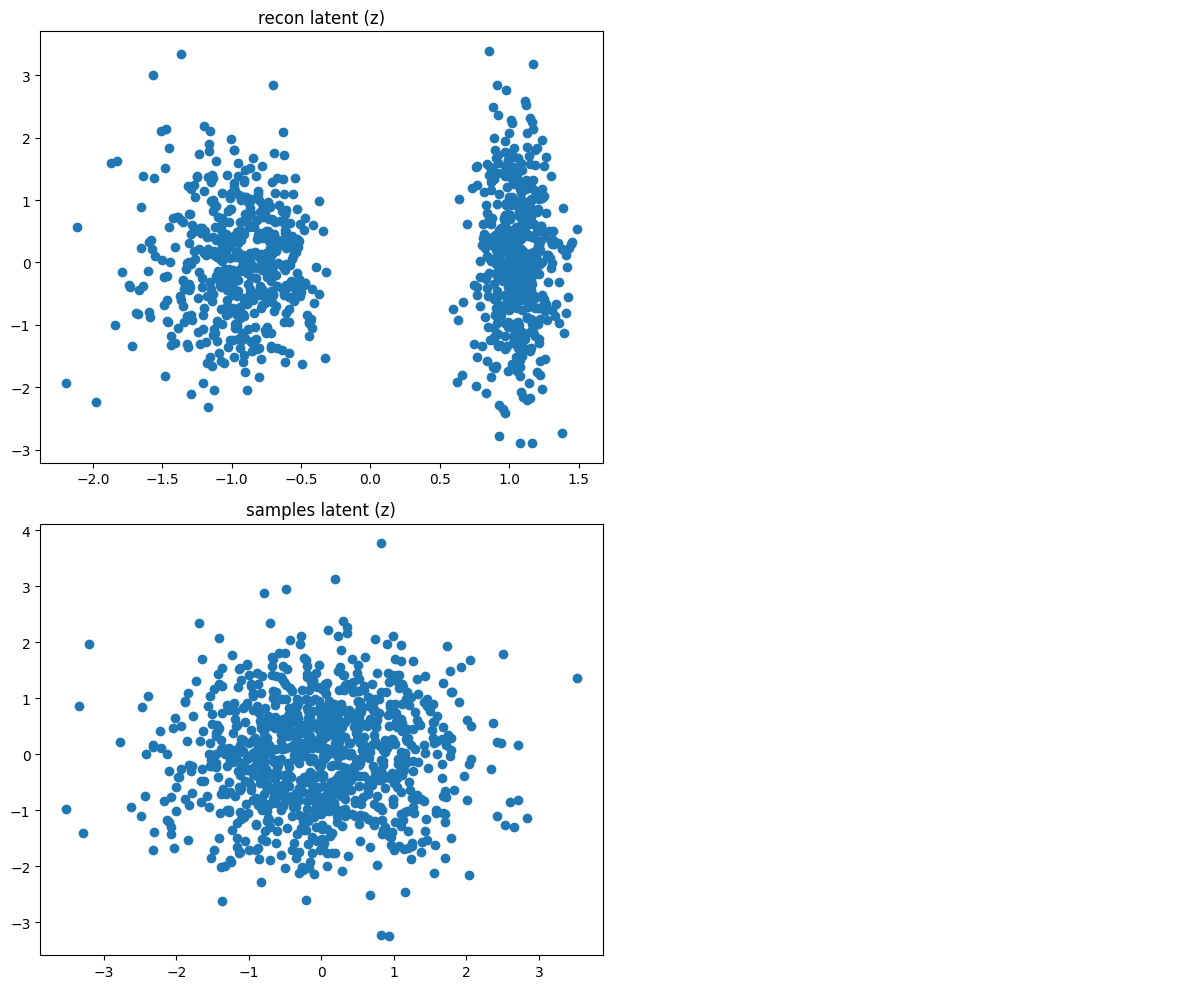

In [43]:
plot_vae(base_vae, sub_key)

# A global Parameter


In [44]:
rng_key, sub_key = jax.random.split(rng_key)

global_vae = GlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




100%|██████████| 10000/10000 [00:08<00:00, 1244.27it/s]


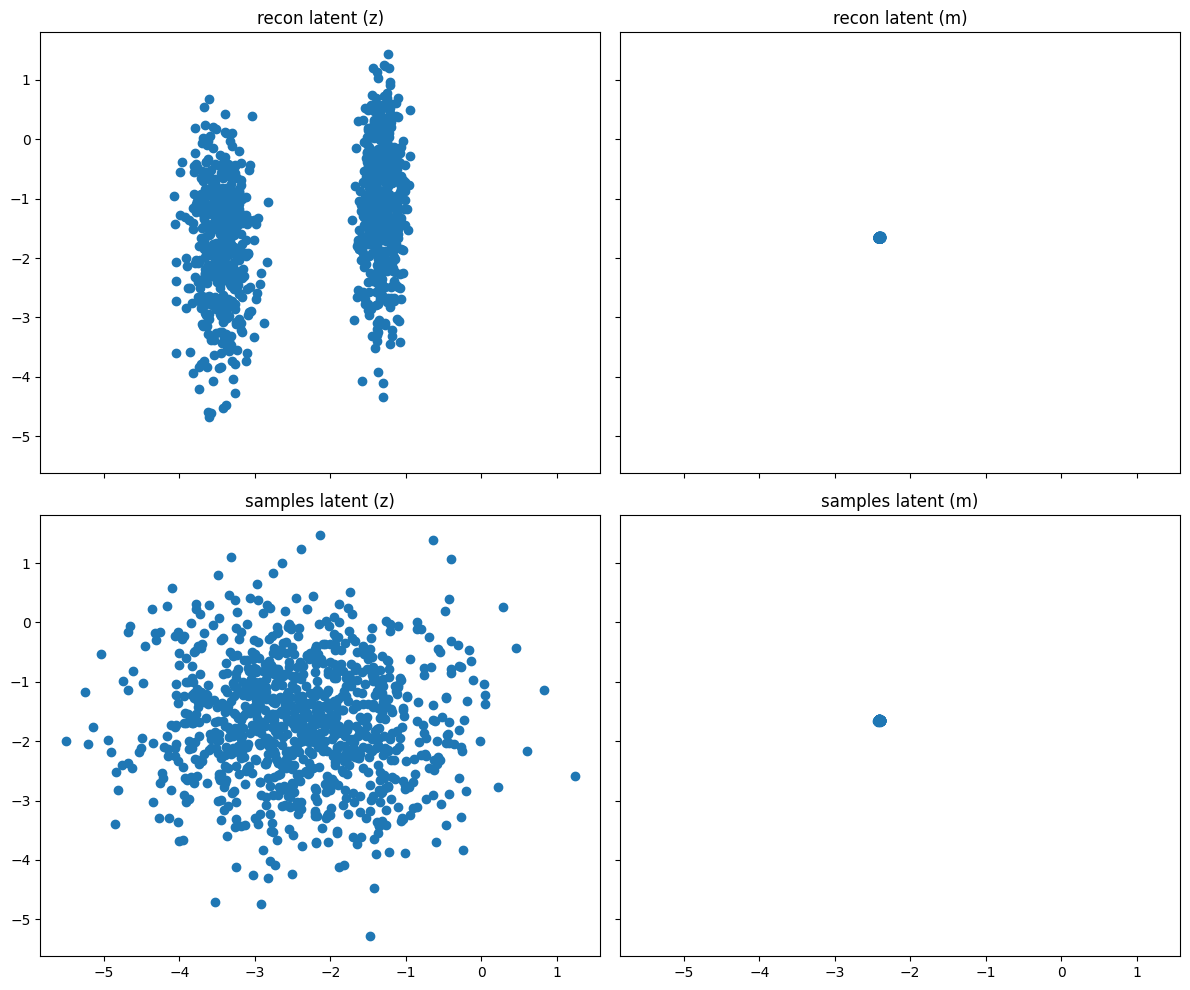

In [55]:
plot_vae(global_vae, sub_key, True)

# Adding a normalizing flow

In [56]:
rng_key, sub_key = jax.random.split(rng_key)


flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": False}

flow_vae = NormalizingGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

flow_vae.train(dataloader, X.shape[0], adam, 5000, sub_key)



100%|██████████| 5000/5000 [00:20<00:00, 243.65it/s] 


In [57]:
plot_vae(flow_vae, sub_key)

TypeError: plot_vae() missing 1 required positional argument: 'share_axis'

# Implementing the stein mixture Flow



In [48]:
rng_key, sub_key = jax.random.split(rng_key)


flow_args = {"input_dim": z_dim, "hidden_dims": [2,2], "steps": 5, "inv": False}

stein_flow_vae = SteinNormalizingVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

stein_flow_vae.train(dataloader, X.shape[0], adam, 5000, sub_key, num_stein_particles=3, repulsion_temperature=1)




100%|██████████| 5000/5000 [00:57<00:00, 87.28it/s]  


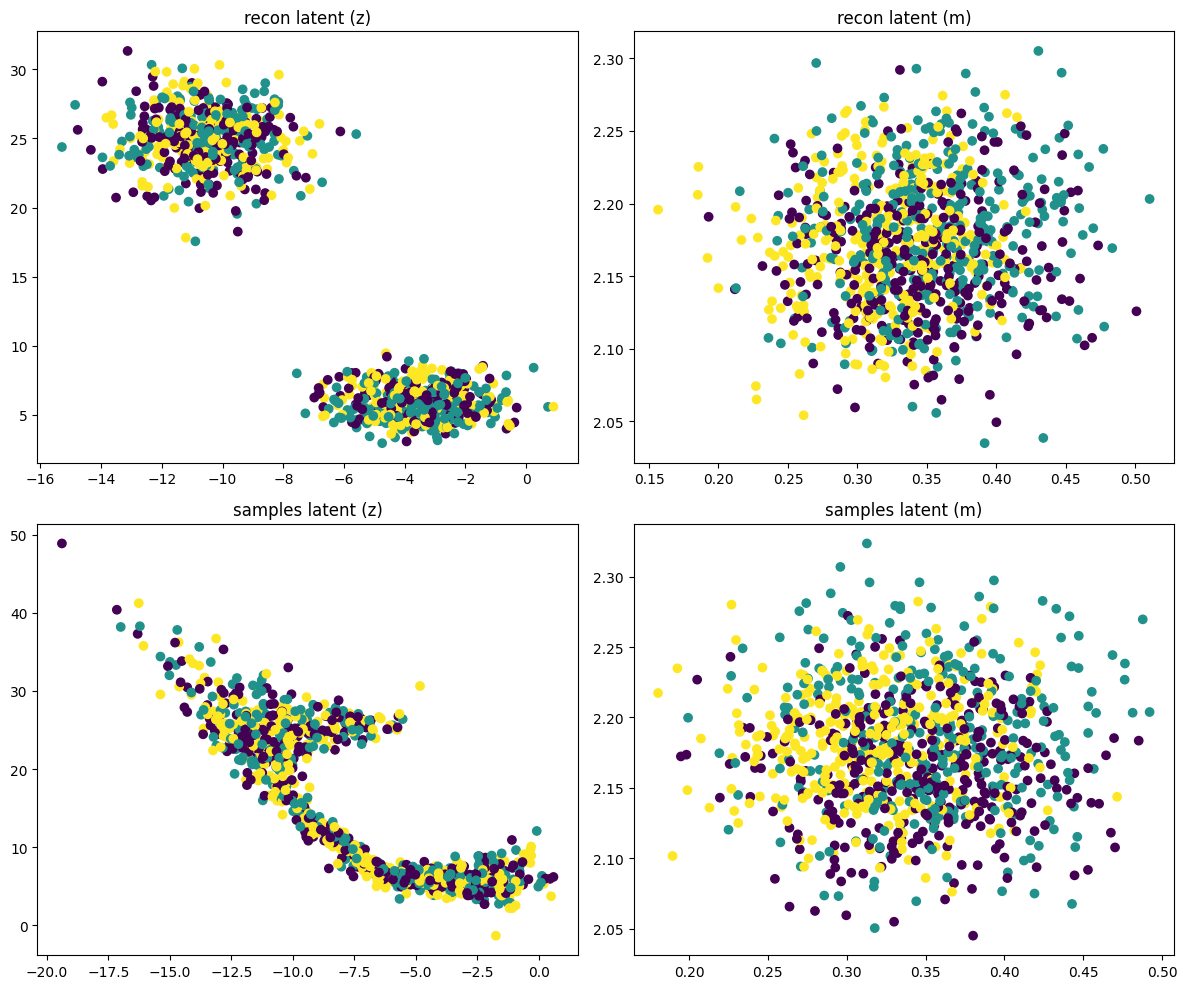

In [49]:
plot_vae(stein_flow_vae, sub_key)

In [84]:
stein_flow_vae.params["a"]

Array([[ 1.1119959 , -1.2878723 ],
       [-0.42923594, -0.14888082],
       [-0.42163125, -1.1045015 ]], dtype=float32)

# Stein global

In [51]:
rng_key, sub_key = jax.random.split(rng_key)

stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

stein_global_vae.train(dataloader, X.shape[0], adam, 5000, sub_key, 3, repulsion_temperature=1)




100%|██████████| 5000/5000 [00:15<00:00, 330.06it/s]


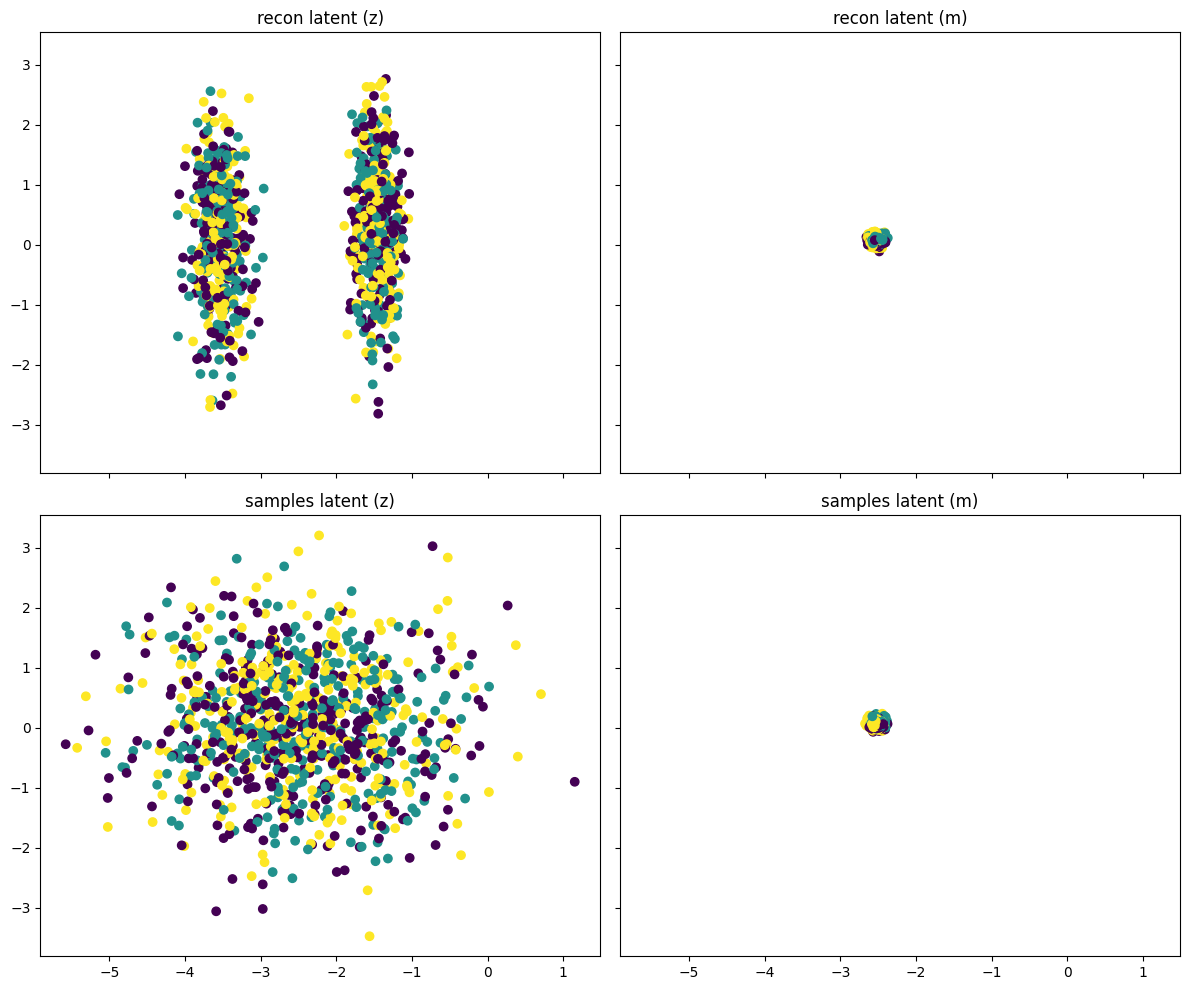

In [52]:
plot_vae(stein_global_vae, sub_key, True, True)